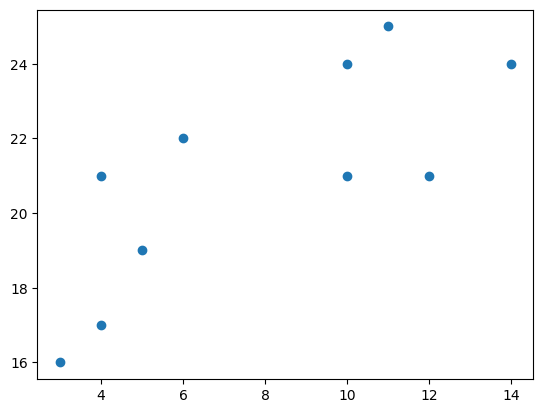

In [ ]:
import matplotlib.pyplot as plt

x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

plt.scatter(x, y)

plt.show()

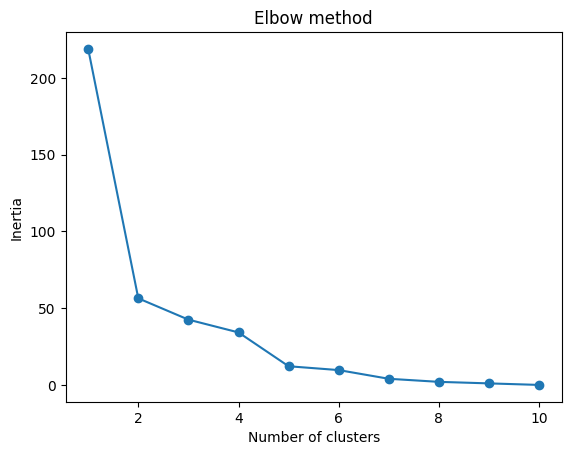

In [ ]:
from sklearn.cluster import KMeans

data = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

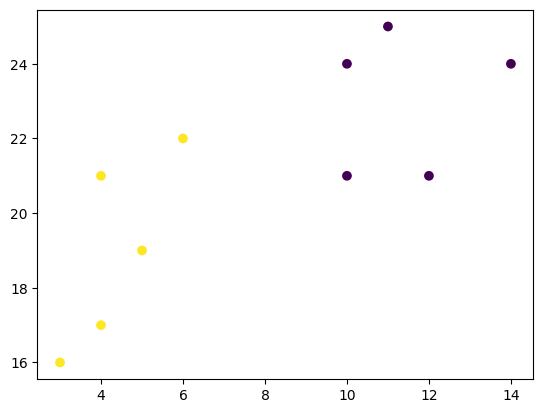

In [ ]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()

In [ ]:
class TreeNode:
  def __init__(self, data):
    self.data = data
    self.left = None
    self.right = None
    self.height = 1

def getHeight(node):
  if not node:
    return 0
  return node.height

def getBalance(node):
  if not node:
    return 0
  return getHeight(node.left) - getHeight(node.right)

def rightRotate(y):
  print('Rotate right on node',y.data)
  x = y.left
  T2 = x.right
  x.right = y
  y.left = T2
  y.height = 1 + max(getHeight(y.left), getHeight(y.right))
  x.height = 1 + max(getHeight(x.left), getHeight(x.right))
  return x

def leftRotate(x):
  print('Rotate left on node',x.data)
  y = x.right
  T2 = y.left
  y.left = x
  x.right = T2
  x.height = 1 + max(getHeight(x.left), getHeight(x.right))
  y.height = 1 + max(getHeight(y.left), getHeight(y.right))
  return y

def insert(node, data):
  if not node:
    return TreeNode(data)

  if data < node.data:
    node.left = insert(node.left, data)
  elif data > node.data:
    node.right = insert(node.right, data)

  # Update the balance factor and balance the tree
  node.height = 1 + max(getHeight(node.left), getHeight(node.right))
  balance = getBalance(node)

  # Balancing the tree
  # Left Left
  if balance > 1 and getBalance(node.left) >= 0:
    return rightRotate(node)

  # Left Right
  if balance > 1 and getBalance(node.left) < 0:
    node.left = leftRotate(node.left)
    return rightRotate(node)

  # Right Right
  if balance < -1 and getBalance(node.right) <= 0:
    return leftRotate(node)

  # Right Left
  if balance < -1 and getBalance(node.right) > 0:
    node.right = rightRotate(node.right)
    return leftRotate(node)

  return node

def inOrderTraversal(node):
  if node is None:
    return
  inOrderTraversal(node.left)
  print(node.data, end=", ")
  inOrderTraversal(node.right)

# Inserting nodes
root = None
letters = ['C', 'B', 'E', 'A', 'D', 'H', 'G', 'F']
for letter in letters:
  root = insert(root, letter)

inOrderTraversal(root)

Rotate right on node H
A, B, C, D, E, F, G, H, 

In [ ]:
def minValueNode(node):
  current = node
  while current.left is not None:
    current = current.left
  return current

def delete(node, data):
  if not node:
    return node

  if data < node.data:
    node.left = delete(node.left, data)
  elif data > node.data:
    node.right = delete(node.right, data)
  else:
    if node.left is None:
      temp = node.right
      node = None
      return temp
    elif node.right is None:
      temp = node.left
      node = None
      return temp

    temp = minValueNode(node.right)
    node.data = temp.data
    node.right = delete(node.right, temp.data)

  return node

def inOrderTraversal(node):
  if node is None:
    return
  inOrderTraversal(node.left)
  print(node.data, end=", ")
  inOrderTraversal(node.right)

# Inserting nodes
root = None
letters = ['C', 'B', 'E', 'A', 'D', 'H', 'G', 'F']
for letter in letters:
  root = insert(root, letter)

inOrderTraversal(root)


Rotate right on node H
A, B, C, D, E, F, G, H, 